In [31]:
from pathlib import Path
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
  roc_curve,
  precision_recall_curve,
  confusion_matrix,
)
import matplotlib.pyplot as plt


# PROJECT_ROOT = Path(__file__).resolve().parent.parent
# os.chdir(PROJECT_ROOT)
Path.cwd(), os.listdir()

(PosixPath('/Users/samuelsonowo/Desktop/Dev/Strata/notebook'),
 ['mas_eval.ipynb'])

In [11]:
preds = pd.read_csv("../artifacts/eval/mas_predictions.csv")

with open("../artifacts/eval/mas_metrics.json") as f:
  metrics = json.load(f)

preds.head()

,row_index,y_true,y_proba,y_pred,triage_label,diagnostic_label
0,0,0,0.944983,1,critical,high_risk
1,1,0,0.338645,0,medium,normal
2,2,0,0.365401,0,medium,normal
3,3,0,0.097013,0,low,normal
4,4,0,0.320665,0,medium,normal


In [ ]:
# with open("../artifacts/eval/mas_metrics.json") as f:
#     metrics = json.load(f)

score = {
  "accuracy": metrics["accuracy"],
  "f1": metrics["f1"]
}
print(score)

{'accuracy': 0.7339187320717337, 'f1': 0.3983013276710922}


In [35]:
df_metrics = pd.DataFrame(
  {
    # "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    # "Metric": ["Accuracy"],
    # "Metric": ["Precision", "Recall"],
    # "Metric": ["F1 Score"],
    "Metric": ["ROC-AUC"],
    "Value": [
      # metrics["accuracy"],
      # metrics["precision"],
      # metrics["recall"],
      # metrics["f1"],
      metrics["roc_auc"],
    ],
  }
)

df_metrics


,Metric,Value
0,ROC-AUC,0.958654


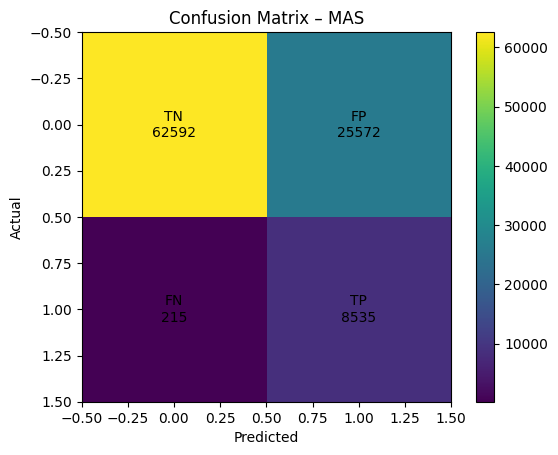

In [12]:
cm = confusion_matrix(preds["y_true"], preds["y_pred"])

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix – MAS")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{labels[i][j]}\n{cm[i,j]}", ha="center", va="center")

plt.show()

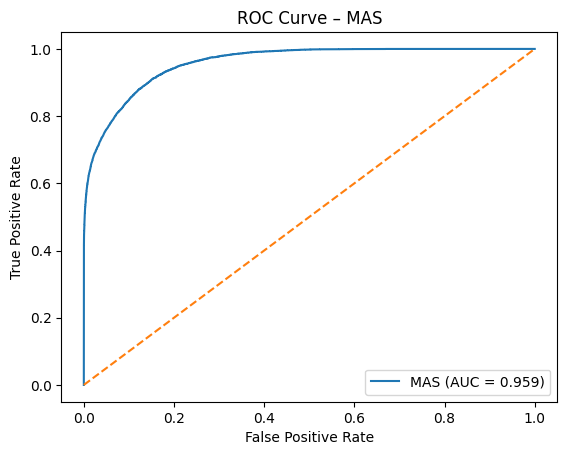

In [13]:
fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_proba"])

plt.figure()
plt.plot(fpr, tpr, label=f"MAS (AUC = {metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MAS")
plt.legend()
plt.show()

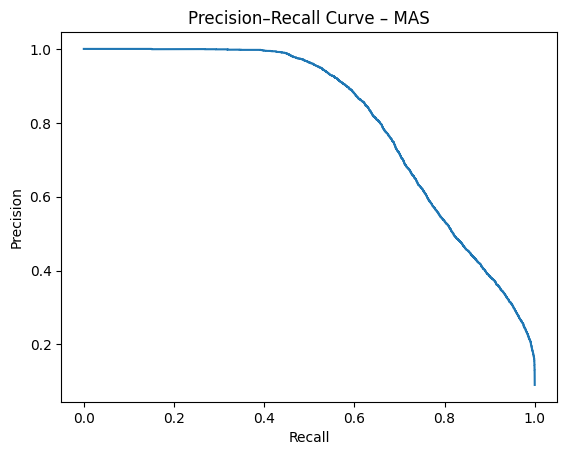

In [14]:
precision, recall, _ = precision_recall_curve(
    preds["y_true"], preds["y_proba"]
)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – MAS")
plt.show()


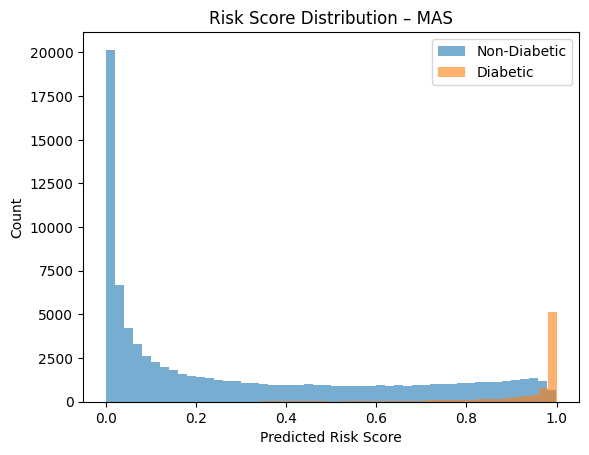

In [15]:
plt.figure()
plt.hist(
    preds[preds["y_true"] == 0]["y_proba"],
    bins=50,
    alpha=0.6,
    label="Non-Diabetic"
)
plt.hist(
    preds[preds["y_true"] == 1]["y_proba"],
    bins=50,
    alpha=0.6,
    label="Diabetic"
)

plt.xlabel("Predicted Risk Score")
plt.ylabel("Count")
plt.title("Risk Score Distribution – MAS")
plt.legend()
plt.show()


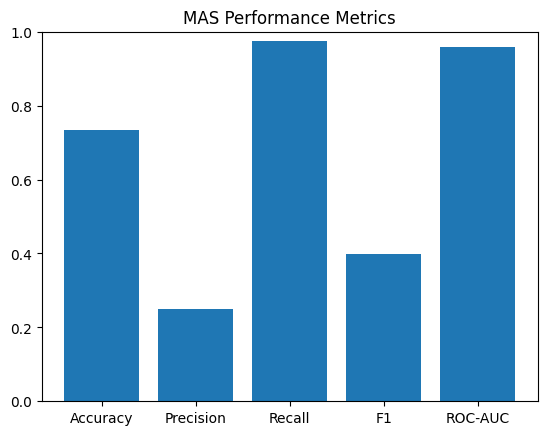

In [16]:
names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
values = [
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1"],
    metrics["roc_auc"],
]

plt.figure()
plt.bar(names, values)
plt.ylim(0, 1)
plt.title("MAS Performance Metrics")
plt.show()


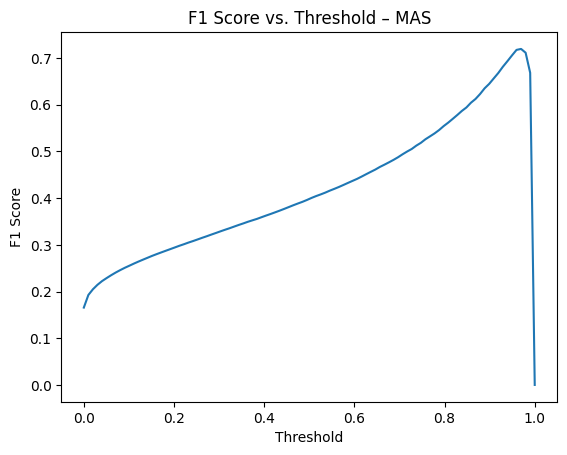

In [32]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0, 1, 100)
f1_scores = [
  f1_score(preds["y_true"], preds["y_proba"] >= t)
  for t in thresholds
]

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold – MAS")
plt.show()

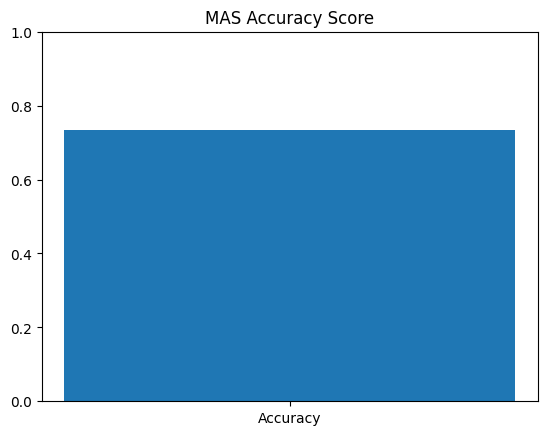

In [33]:
plt.figure()
plt.bar(["Accuracy"], [metrics["accuracy"]])
plt.ylim(0, 1)
plt.title("MAS Accuracy Score")
plt.show()